# Sweep Hyperparameter Analysis

Analysis of the continual learning sweep comparing BP vs EFC across different settings.
This notebook identifies the best hyperparameters for each method and dataset.

In [1]:
import os
import json
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [2]:
# Configure your sweep IDs here (can be a single ID or a list)
SWEEP_IDS = [
    # "xlaev4nn",  # Replace with your actual sweep IDs
    "w0d4usvi",
    "4ebj902x",
]
WANDB_DIR = Path("./wandb")

In [3]:
def load_sweep_results_with_hyperparams(sweep_ids: list, wandb_dir: Path) -> pd.DataFrame:
    """Load all run results including hyperparameters from multiple sweeps."""
    all_results = []
    
    for sweep_id in sweep_ids:
        sweep_dir = wandb_dir / f"sweep-{sweep_id}"
        if not sweep_dir.exists():
            print(f"Warning: Sweep directory not found for {sweep_id}")
            continue
            
        print(f"Loading sweep: {sweep_id}")
        
        # Get all run IDs from sweep config files
        for config_file in sweep_dir.glob("config-*.yaml"):
            run_id = config_file.stem.replace("config-", "")
            
            # Find the corresponding run directory
            run_dirs = list(wandb_dir.glob(f"run-*-{run_id}"))
            if not run_dirs:
                continue
            
            run_dir = run_dirs[0]
            
            # Load config from sweep directory
            with open(config_file) as f:
                config = yaml.safe_load(f)
            
            # Load summary from run directory
            summary_file = run_dir / "files" / "wandb-summary.json"
            if not summary_file.exists():
                continue
                
            with open(summary_file) as f:
                summary = json.load(f)
            
            # Helper to extract value from config
            def get_config_value(key):
                val = config.get(key, {})
                if isinstance(val, dict):
                    return val.get("value")
                return val
            
            # Extract all relevant info including hyperparameters
            result = {
                "sweep_id": sweep_id,
                "run_id": run_id,
                "setting": get_config_value("setting"),
                "method": get_config_value("method"),
                "seed": get_config_value("seed"),
                "lr": get_config_value("lr"),
                "beta_efc": get_config_value("beta_efc"),
                "target_lr": get_config_value("target_lr"),
                "batch_size": get_config_value("batch_size"),
                "epochs": get_config_value("epochs"),
                "final_avg_accuracy": summary.get("final_avg_accuracy"),
                "final_forgetting": summary.get("final_forgetting"),
                "layer_size": get_config_value("layer_size"),
                "cnn_pretrained": get_config_value("cnn_pretrained")
            }
            all_results.append(result)
    
    return pd.DataFrame(all_results)

In [4]:
# Load all results from all sweeps
df = load_sweep_results_with_hyperparams(SWEEP_IDS, WANDB_DIR)

# Only select runs for which CNN pretrained = true
df = df[df["cnn_pretrained"] == True]

print(f"Loaded {len(df)} runs from {df['sweep_id'].nunique()} sweep(s)")
print(f"\nSweep IDs: {df['sweep_id'].unique().tolist()}")
print(f"Settings: {df['setting'].unique().tolist()}")
print(f"Methods: {df['method'].unique().tolist()}")
print(f"Learning rates: {sorted(df['lr'].dropna().unique().tolist())}") 
print(f"Beta EFC values: {sorted(df['beta_efc'].dropna().unique().tolist())}")
print(f"Target LR values: {sorted(df['target_lr'].dropna().unique().tolist())}")
df.head(10)

Loading sweep: w0d4usvi
Loading sweep: 4ebj902x
Loaded 381 runs from 2 sweep(s)

Sweep IDs: ['w0d4usvi', '4ebj902x']
Settings: ['ClassILMNIST5Task', 'ClassILMNIST5Task_Encoded', 'TaskILMNIST5Task_Encoded', 'TaskILCIFAR10', 'ClassILCIFAR5Task', 'TaskILTinyImageNet', 'ClassILTinyImageNet10Task']
Methods: ['efc']
Learning rates: [1e-05, 3e-05, 0.0001]
Beta EFC values: [1, 10]
Target LR values: [0.01, 0.1, 1.0]


,sweep_id,run_id,setting,method,seed,lr,beta_efc,target_lr,batch_size,epochs,final_avg_accuracy,final_forgetting,layer_size,cnn_pretrained
0,w0d4usvi,jem9hsh2,ClassILMNIST5Task,efc,3,0.00001,10,1.00,256,20,49.190000,None,100,True
1,w0d4usvi,c9lzuyxf,ClassILMNIST5Task,efc,3,0.00001,10,0.10,256,20,53.540000,None,100,True
2,w0d4usvi,xycx5dz5,ClassILMNIST5Task,efc,3,0.00001,10,0.01,256,20,49.670000,None,100,True
3,w0d4usvi,lzib8jpc,ClassILMNIST5Task_Encoded,efc,3,0.00001,10,1.00,256,20,33.020000,None,100,True
4,w0d4usvi,8q7f9sia,ClassILMNIST5Task_Encoded,efc,3,0.00001,10,0.10,256,20,50.300000,None,100,True
5,w0d4usvi,i6ynomcs,ClassILMNIST5Task_Encoded,efc,3,0.00001,10,0.01,256,20,30.660000,None,100,True
6,w0d4usvi,km2rqj9x,TaskILMNIST5Task_Encoded,efc,3,0.00001,10,1.00,256,20,94.327660,None,100,True
7,w0d4usvi,orsez4vw,TaskILMNIST5Task_Encoded,efc,3,0.00001,10,0.10,256,20,93.080398,None,100,True
8,w0d4usvi,tgvtyxu3,TaskILMNIST5Task_Encoded,efc,3,0.00001,10,0.01,256,20,98.283526,None,100,True
9,w0d4usvi,i2d36i7p,TaskILCIFAR10,efc,3,0.00001,10,1.00,256,20,95.660000,None,100,True


## 1. Data Completeness Check

In [5]:
# Check runs per setting/method/hyperparameter combination
print("Runs per setting and method:")
print(df.groupby(["setting", "method"]).size().unstack(fill_value=0))
print("\n" + "="*60)
print("\nRuns per learning rate:")
print(df.groupby(["method", "lr"]).size().unstack(fill_value=0))

Runs per setting and method:
method                     efc
setting                       
ClassILCIFAR5Task           54
ClassILMNIST5Task           57
ClassILMNIST5Task_Encoded   54
ClassILTinyImageNet10Task   54
TaskILCIFAR10               54
TaskILMNIST5Task_Encoded    54
TaskILTinyImageNet          54


Runs per learning rate:
lr      0.00001  0.00003  0.00010
method                           
efc         129      126      126


## 2. Best Hyperparameters per Method and Setting

For each (setting, method) combination, find the hyperparameter configuration that achieves the best average accuracy across seeds.

In [6]:
# For BP: only lr matters (beta_efc and target_lr are EFC-specific)
# For EFC: lr, beta_efc, and target_lr all matter

def find_best_hyperparams(df, method):
    """Find best hyperparameters for a given method across all settings."""
    method_df = df[df['method'] == method].copy()
    
    if method == 'bp':
        # Group by setting and lr, average over seeds
        grouped = method_df.groupby(['setting', 'lr']).agg({
            'final_avg_accuracy': ['mean', 'std', 'count']
        }).reset_index()
        grouped.columns = ['setting', 'lr', 'mean_acc', 'std_acc', 'n_seeds']
        
        # Find best lr for each setting
        best = grouped.loc[grouped.groupby('setting')['mean_acc'].idxmax()]
        best = best.sort_values('setting')
        return best
    
    else:  # EFC
        # Group by setting, lr, beta_efc, target_lr, average over seeds
        grouped = method_df.groupby(['setting', 'lr', 'beta_efc', 'target_lr']).agg({
            'final_avg_accuracy': ['mean', 'std', 'count']
        }).reset_index()
        grouped.columns = ['setting', 'lr', 'beta_efc', 'target_lr', 'mean_acc', 'std_acc', 'n_seeds']
        
        # Find best hyperparams for each setting
        best = grouped.loc[grouped.groupby('setting')['mean_acc'].idxmax()]
        best = best.sort_values('setting')
        return best

In [7]:
# Best hyperparameters for BP
print("="*80)
print("BEST HYPERPARAMETERS FOR BP")
print("="*80)
best_bp = find_best_hyperparams(df, 'bp')
print(best_bp.to_string(index=False))

BEST HYPERPARAMETERS FOR BP
Empty DataFrame
Columns: [setting, lr, mean_acc, std_acc, n_seeds]
Index: []


In [8]:
# Best hyperparameters for EFC
print("="*80)
print("BEST HYPERPARAMETERS FOR EFC")
print("="*80)
best_efc = find_best_hyperparams(df, 'efc')
print(best_efc.to_string(index=False))

BEST HYPERPARAMETERS FOR EFC
                  setting      lr  beta_efc  target_lr  mean_acc  std_acc  n_seeds
        ClassILCIFAR5Task 0.00003        10       1.00 48.513333 2.254388        6
        ClassILMNIST5Task 0.00001        10       0.10 50.561667 3.982132        6
ClassILMNIST5Task_Encoded 0.00001        10       0.10 47.416667 4.025914        6
ClassILTinyImageNet10Task 0.00010        10       0.01  2.290000 0.459946        5
            TaskILCIFAR10 0.00003        10       1.00 95.910000 0.432157        6
 TaskILMNIST5Task_Encoded 0.00001        10       0.01 98.032466 0.600635        6
       TaskILTinyImageNet 0.00003        10       1.00 26.175000 0.554428        6


In [10]:
# Create a combined summary table
print("="*80)
print("SUMMARY: BEST ACCURACY WITH OPTIMAL HYPERPARAMETERS")
print("="*80)

# Print number of seeds used
n_seeds = df['seed'].nunique()
print(f"Number of seeds: {n_seeds}")
print(f"Seeds: {sorted(df['seed'].dropna().unique().tolist())}")
print()

# Use available settings from data instead of hardcoded list
available_settings = df['setting'].unique().tolist()
setting_order = [s for s in [
    "ClassILMNIST5Task",
    "ClassILCIFAR5Task",
    "ClassILTinyImageNet10Task"
] if s in available_settings]
# Add any settings not in the predefined order
setting_order += [s for s in available_settings if s not in setting_order]

summary_rows = []
for setting in setting_order:
    bp_row = best_bp[best_bp['setting'] == setting] if len(best_bp) > 0 else pd.DataFrame()
    efc_row = best_efc[best_efc['setting'] == setting] if len(best_efc) > 0 else pd.DataFrame()
    
    row = {'Setting': setting}
    
    if len(efc_row) > 0:
        efc_data = efc_row.iloc[0]
        row['EFC Accuracy'] = f"{efc_data['mean_acc']:.2f} +/- {efc_data['std_acc']:.2f}"
        row["n_seeds"] = efc_data['n_seeds']
        row['EFC lr'] = efc_data['lr']
        row['EFC beta'] = efc_data['beta_efc']
        row['EFC target_lr'] = efc_data['target_lr']
    
    if len(bp_row) > 0:
        bp_data = bp_row.iloc[0]
        row['BP Accuracy'] = f"{bp_data['mean_acc']:.2f} +/- {bp_data['std_acc']:.2f}"
        row['BP lr'] = bp_data['lr']
        if len(efc_row) > 0:
            row['Delta (EFC-BP)'] = efc_data['mean_acc'] - bp_data['mean_acc']
    
    if len(row) > 1:  # Only add if we have some data
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

SUMMARY: BEST ACCURACY WITH OPTIMAL HYPERPARAMETERS
Number of seeds: 6
Seeds: [0, 1, 2, 3, 4, 5]

                  Setting   EFC Accuracy  n_seeds  EFC lr  EFC beta  EFC target_lr
        ClassILMNIST5Task 50.56 +/- 3.98        6 0.00001        10           0.10
        ClassILCIFAR5Task 48.51 +/- 2.25        6 0.00003        10           1.00
ClassILTinyImageNet10Task  2.29 +/- 0.46        5 0.00010        10           0.01
ClassILMNIST5Task_Encoded 47.42 +/- 4.03        6 0.00001        10           0.10
 TaskILMNIST5Task_Encoded 98.03 +/- 0.60        6 0.00001        10           0.01
            TaskILCIFAR10 95.91 +/- 0.43        6 0.00003        10           1.00
       TaskILTinyImageNet 26.18 +/- 0.55        6 0.00003        10           1.00


## 3. Hyperparameter Sensitivity Analysis

In [14]:
# Learning rate sensitivity for BP
bp_df = df[df['method'] == 'bp']
bp_settings = [s for s in setting_order if s in bp_df['setting'].unique()]

if len(bp_settings) > 0:
    n_plots = len(bp_settings)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    for idx, setting in enumerate(bp_settings):
        setting_df = bp_df[bp_df['setting'] == setting]
        lr_stats = setting_df.groupby('lr')['final_avg_accuracy'].agg(['mean', 'std']).reset_index()
        
        ax = axes[idx]
        ax.errorbar(range(len(lr_stats)), lr_stats['mean'], yerr=lr_stats['std'], 
                    marker='o', capsize=5, capthick=2, linewidth=2, markersize=8)
        ax.set_xticks(range(len(lr_stats)))
        ax.set_xticklabels([f"{lr:.0e}" for lr in lr_stats['lr']], rotation=45)
        ax.set_xlabel('Learning Rate')
        ax.set_ylabel('Final Avg Accuracy (%)')
        ax.set_title(f'BP - {setting}')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle('BP: Learning Rate Sensitivity', y=1.02, fontsize=14, fontweight='bold')
    plt.savefig('bp_lr_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No BP data available - skipping BP learning rate sensitivity plot")

No BP data available - skipping BP learning rate sensitivity plot


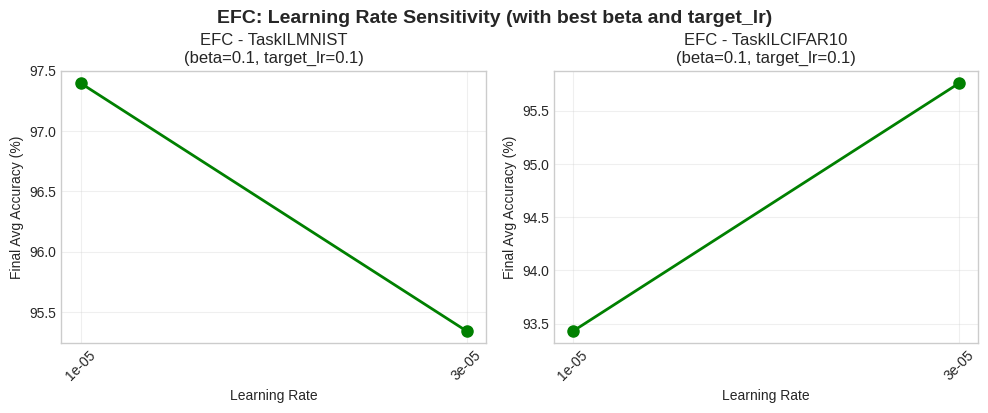

In [10]:
# Learning rate sensitivity for EFC (fixing beta_efc and target_lr to best values)
efc_df = df[df['method'] == 'efc']
efc_settings = [s for s in setting_order if s in efc_df['setting'].unique() and s in best_efc['setting'].values]

if len(efc_settings) > 0:
    n_plots = len(efc_settings)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    for idx, setting in enumerate(efc_settings):
        setting_df = efc_df[efc_df['setting'] == setting]
        
        best_rows = best_efc[best_efc['setting'] == setting]
        best_beta = best_rows.iloc[0]['beta_efc']
        best_target = best_rows.iloc[0]['target_lr']

        # Filter to best beta and target_lr
        filtered_df = setting_df[(setting_df['beta_efc'] == best_beta) & 
                                 (setting_df['target_lr'] == best_target)]
        lr_stats = filtered_df.groupby('lr')['final_avg_accuracy'].agg(['mean', 'std']).reset_index()
        
        ax = axes[idx]
        ax.errorbar(range(len(lr_stats)), lr_stats['mean'], yerr=lr_stats['std'], 
                    marker='o', capsize=5, capthick=2, linewidth=2, markersize=8, color='green')
        ax.set_xticks(range(len(lr_stats)))
        ax.set_xticklabels([f"{lr:.0e}" for lr in lr_stats['lr']], rotation=45)
        ax.set_xlabel('Learning Rate')
        ax.set_ylabel('Final Avg Accuracy (%)')
        ax.set_title(f'EFC - {setting}\n(beta={best_beta}, target_lr={best_target})')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle('EFC: Learning Rate Sensitivity (with best beta and target_lr)', y=1.02, fontsize=14, fontweight='bold')
    plt.savefig('efc_lr_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No EFC data available - skipping EFC learning rate sensitivity plot")

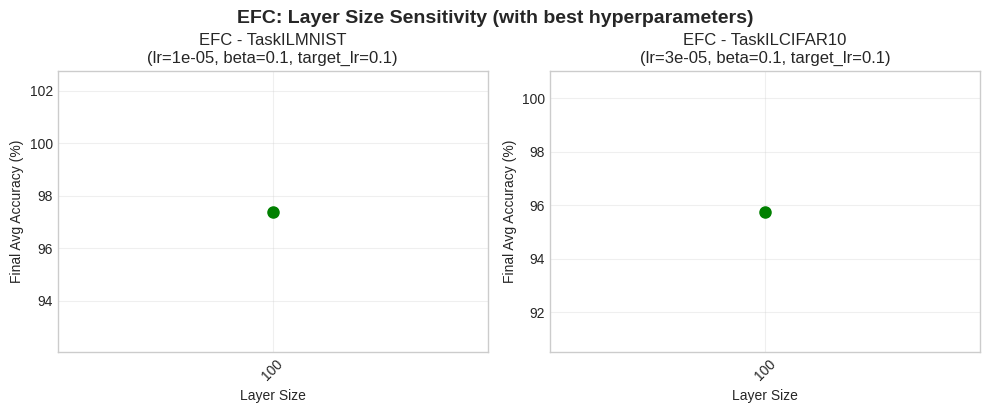

In [11]:
# Layer size sensitivity for EFC (fixing lr, beta_efc and target_lr to best values)
efc_df = df[df['method'] == 'efc']
efc_settings = [s for s in setting_order if s in efc_df['setting'].unique() and s in best_efc['setting'].values]

if len(efc_settings) > 0:
    n_plots = len(efc_settings)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    for idx, setting in enumerate(efc_settings):
        setting_df = efc_df[efc_df['setting'] == setting]
        
        best_rows = best_efc[best_efc['setting'] == setting]
        best_lr = best_rows.iloc[0]['lr']
        best_beta = best_rows.iloc[0]['beta_efc']
        best_target = best_rows.iloc[0]['target_lr']

        # Filter to best lr, beta and target_lr
        filtered_df = setting_df[(setting_df['lr'] == best_lr) &
                                 (setting_df['beta_efc'] == best_beta) & 
                                 (setting_df['target_lr'] == best_target)]
        layer_stats = filtered_df.groupby('layer_size')['final_avg_accuracy'].agg(['mean', 'std']).reset_index()
        
        ax = axes[idx]
        ax.errorbar(range(len(layer_stats)), layer_stats['mean'], yerr=layer_stats['std'], 
                    marker='o', capsize=5, capthick=2, linewidth=2, markersize=8, color='green')
        ax.set_xticks(range(len(layer_stats)))
        ax.set_xticklabels([str(ls) for ls in layer_stats['layer_size']], rotation=45)
        ax.set_xlabel('Layer Size')
        ax.set_ylabel('Final Avg Accuracy (%)')
        ax.set_title(f'EFC - {setting}\n(lr={best_lr:.0e}, beta={best_beta}, target_lr={best_target})')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle('EFC: Layer Size Sensitivity (with best hyperparameters)', y=1.02, fontsize=14, fontweight='bold')
    plt.savefig('efc_layer_size_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No EFC data available - skipping EFC layer size sensitivity plot")


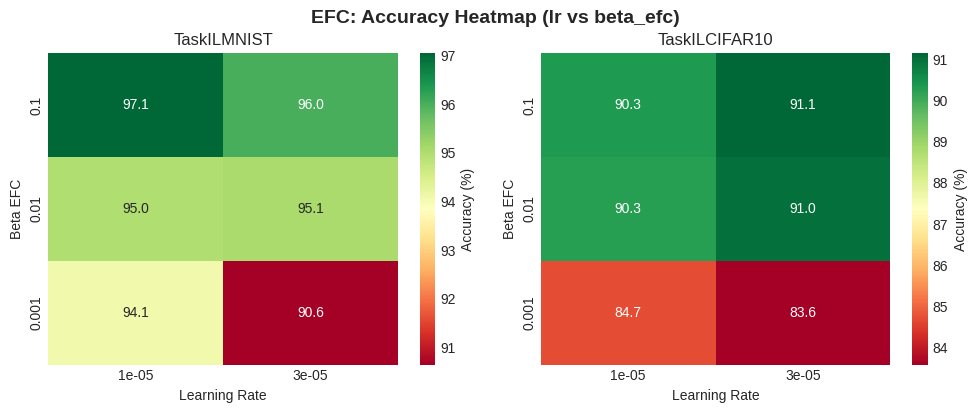

In [12]:
# Beta EFC heatmap for each setting (averaging over target_lr and seeds)
efc_df = df[df['method'] == 'efc']
efc_settings = [s for s in setting_order if s in efc_df['setting'].unique()]

if len(efc_settings) > 0:
    n_plots = len(efc_settings)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    for idx, setting in enumerate(efc_settings):
        setting_df = efc_df[efc_df['setting'] == setting]
        
        # Create pivot table: lr vs beta_efc
        pivot = setting_df.pivot_table(
            values='final_avg_accuracy',
            index='beta_efc',
            columns='lr',
            aggfunc='mean'
        )
        
        # Sort index and columns
        pivot = pivot.sort_index(ascending=False)
        pivot = pivot[sorted(pivot.columns)]
        
        ax = axes[idx]
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax, 
                    cbar_kws={'label': 'Accuracy (%)'})
        ax.set_xlabel('Learning Rate')
        ax.set_ylabel('Beta EFC')
        ax.set_title(f'{setting}')

    plt.tight_layout()
    plt.suptitle('EFC: Accuracy Heatmap (lr vs beta_efc)', y=1.02, fontsize=14, fontweight='bold')
    plt.savefig('efc_lr_beta_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No EFC data available - skipping beta heatmap")

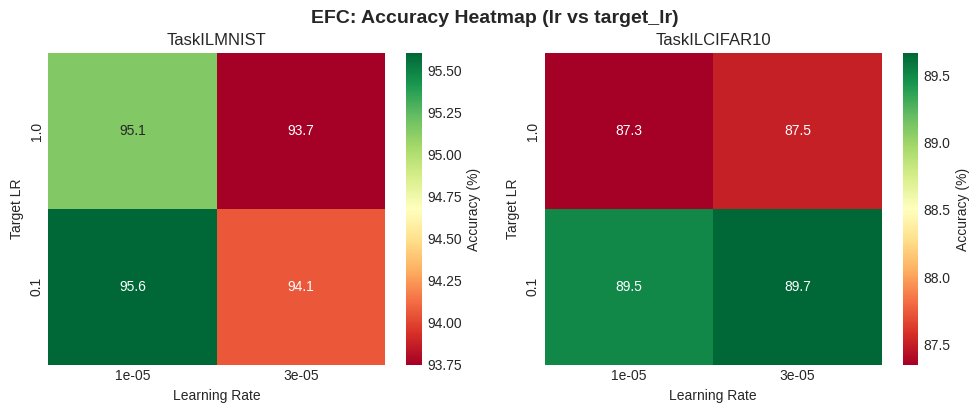

In [13]:
# Target LR heatmap for each setting (averaging over beta_efc and seeds)
efc_df = df[df['method'] == 'efc']
efc_settings = [s for s in setting_order if s in efc_df['setting'].unique()]

if len(efc_settings) > 0:
    n_plots = len(efc_settings)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    for idx, setting in enumerate(efc_settings):
        setting_df = efc_df[efc_df['setting'] == setting]
        
        # Create pivot table: lr vs target_lr
        pivot = setting_df.pivot_table(
            values='final_avg_accuracy',
            index='target_lr',
            columns='lr',
            aggfunc='mean'
        )
        
        # Sort index and columns
        pivot = pivot.sort_index(ascending=False)
        pivot = pivot[sorted(pivot.columns)]
        
        ax = axes[idx]
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
                    cbar_kws={'label': 'Accuracy (%)'})
        ax.set_xlabel('Learning Rate')
        ax.set_ylabel('Target LR')
        ax.set_title(f'{setting}')

    plt.tight_layout()
    plt.suptitle('EFC: Accuracy Heatmap (lr vs target_lr)', y=1.02, fontsize=14, fontweight='bold')
    plt.savefig('efc_lr_target_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No EFC data available - skipping target_lr heatmap")

## 4. Comparison Plot: BP vs EFC (Best Configs)

In [ ]:
# Bar plot comparing BP vs EFC with best hyperparameters
# Only plot settings that have data for at least one method
plot_settings = [s for s in setting_order if 
                 (len(best_bp) > 0 and s in best_bp['setting'].values) or 
                 (len(best_efc) > 0 and s in best_efc['setting'].values)]

if len(plot_settings) > 0:
    fig, ax = plt.subplots(figsize=(max(6, 3*len(plot_settings)), 6))

    x = np.arange(len(plot_settings))
    width = 0.35

    bp_means = []
    bp_stds = []
    efc_means = []
    efc_stds = []

    for setting in plot_settings:
        bp_row = best_bp[best_bp['setting'] == setting] if len(best_bp) > 0 else pd.DataFrame()
        efc_row = best_efc[best_efc['setting'] == setting] if len(best_efc) > 0 else pd.DataFrame()
        
        if len(bp_row) > 0:
            bp_means.append(bp_row.iloc[0]['mean_acc'])
            bp_stds.append(bp_row.iloc[0]['std_acc'])
        else:
            bp_means.append(0)
            bp_stds.append(0)
            
        if len(efc_row) > 0:
            efc_means.append(efc_row.iloc[0]['mean_acc'])
            efc_stds.append(efc_row.iloc[0]['std_acc'])
        else:
            efc_means.append(0)
            efc_stds.append(0)

    # Only plot methods that have data
    has_bp = any(m > 0 for m in bp_means)
    has_efc = any(m > 0 for m in efc_means)

    if has_bp and has_efc:
        bars1 = ax.bar(x - width/2, bp_means, width, yerr=bp_stds, label='BP', 
                       capsize=5, color='steelblue', alpha=0.8)
        bars2 = ax.bar(x + width/2, efc_means, width, yerr=efc_stds, label='EFC', 
                       capsize=5, color='seagreen', alpha=0.8)
    elif has_bp:
        bars1 = ax.bar(x, bp_means, width, yerr=bp_stds, label='BP', 
                       capsize=5, color='steelblue', alpha=0.8)
        bars2 = None
    else:
        bars1 = None
        bars2 = ax.bar(x, efc_means, width, yerr=efc_stds, label='EFC', 
                       capsize=5, color='seagreen', alpha=0.8)

    ax.set_ylabel('Final Avg Accuracy (%)', fontsize=12)
    ax.set_title('BP vs EFC: Best Hyperparameters Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace('ClassIL', 'ClassIL\n').replace('TaskIL', 'TaskIL\n') 
                        for s in plot_settings], fontsize=10)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    if bars1 is not None:
        for bar, mean in zip(bars1, bp_means):
            if mean > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                        f'{mean:.1f}', ha='center', va='bottom', fontsize=9)

    if bars2 is not None:
        for bar, mean in zip(bars2, efc_means):
            if mean > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                        f'{mean:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('bp_vs_efc_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No data available for comparison plot")

## 5. Detailed Hyperparameter Tables

In [ ]:
# Top 5 configurations for each setting (EFC only)
print("="*80)
print("TOP 5 EFC CONFIGURATIONS PER SETTING")
print("="*80)

efc_df = df[df['method'] == 'efc']

if len(efc_df) > 0:
    for setting in setting_order:
        setting_df = efc_df[efc_df['setting'] == setting]
        if len(setting_df) == 0:
            continue
            
        print(f"\n{'='*40}")
        print(f"Setting: {setting}")
        print(f"{'='*40}")
        
        grouped = setting_df.groupby(['lr', 'beta_efc', 'target_lr']).agg({
            'final_avg_accuracy': ['mean', 'std', 'count']
        }).reset_index()
        grouped.columns = ['lr', 'beta_efc', 'target_lr', 'mean_acc', 'std_acc', 'n_seeds']
        
        top5 = grouped.nlargest(5, 'mean_acc')
        print(top5.to_string(index=False))
else:
    print("No EFC data available")

In [ ]:
# Top 5 configurations for each setting (BP only)
print("="*80)
print("TOP 5 BP CONFIGURATIONS PER SETTING")
print("="*80)

bp_df = df[df['method'] == 'bp']

if len(bp_df) > 0:
    for setting in setting_order:
        setting_df = bp_df[bp_df['setting'] == setting]
        if len(setting_df) == 0:
            continue
            
        print(f"\n{'='*40}")
        print(f"Setting: {setting}")
        print(f"{'='*40}")
        
        grouped = setting_df.groupby(['lr']).agg({
            'final_avg_accuracy': ['mean', 'std', 'count']
        }).reset_index()
        grouped.columns = ['lr', 'mean_acc', 'std_acc', 'n_seeds']
        
        top5 = grouped.nlargest(5, 'mean_acc')
        print(top5.to_string(index=False))
else:
    print("No BP data available")

## 6. Export Results

In [ ]:
# Save the full results dataframe
df.to_csv('sweep_results_full.csv', index=False)
print("Saved full results to sweep_results_full.csv")

# Save best hyperparameters (only if data exists)
if len(best_bp) > 0:
    best_bp.to_csv('best_hyperparams_bp.csv', index=False)
    print("Saved best BP hyperparameters to best_hyperparams_bp.csv")
else:
    print("No BP data to save")

if len(best_efc) > 0:
    best_efc.to_csv('best_hyperparams_efc.csv', index=False)
    print("Saved best EFC hyperparameters to best_hyperparams_efc.csv")
else:
    print("No EFC data to save")

In [ ]:
# Final summary for paper/report
print("\n" + "="*80)
print("FINAL SUMMARY FOR PAPER")
print("="*80)
print("\nBest Results (Accuracy %) with optimal hyperparameters:")

has_bp = len(best_bp) > 0
has_efc = len(best_efc) > 0

if has_bp and has_efc:
    print("\n| Setting | BP | EFC | Delta |")
    print("|---------|-----|------|-------|")
    
    for setting in setting_order:
        bp_row = best_bp[best_bp['setting'] == setting]
        efc_row = best_efc[best_efc['setting'] == setting]
        
        if len(bp_row) > 0 and len(efc_row) > 0:
            bp_acc = bp_row.iloc[0]['mean_acc']
            bp_std = bp_row.iloc[0]['std_acc']
            efc_acc = efc_row.iloc[0]['mean_acc']
            efc_std = efc_row.iloc[0]['std_acc']
            delta = efc_acc - bp_acc
            delta_str = f"+{delta:.1f}" if delta > 0 else f"{delta:.1f}"
            
            print(f"| {setting} | {bp_acc:.1f}+/-{bp_std:.1f} | {efc_acc:.1f}+/-{efc_std:.1f} | {delta_str} |")
        elif len(efc_row) > 0:
            efc_acc = efc_row.iloc[0]['mean_acc']
            efc_std = efc_row.iloc[0]['std_acc']
            print(f"| {setting} | - | {efc_acc:.1f}+/-{efc_std:.1f} | - |")
        elif len(bp_row) > 0:
            bp_acc = bp_row.iloc[0]['mean_acc']
            bp_std = bp_row.iloc[0]['std_acc']
            print(f"| {setting} | {bp_acc:.1f}+/-{bp_std:.1f} | - | - |")

elif has_efc:
    print("\n| Setting | EFC |")
    print("|---------|------|")
    
    for setting in setting_order:
        efc_row = best_efc[best_efc['setting'] == setting]
        if len(efc_row) > 0:
            efc_acc = efc_row.iloc[0]['mean_acc']
            efc_std = efc_row.iloc[0]['std_acc']
            print(f"| {setting} | {efc_acc:.1f}+/-{efc_std:.1f} |")

elif has_bp:
    print("\n| Setting | BP |")
    print("|---------|-----|")
    
    for setting in setting_order:
        bp_row = best_bp[best_bp['setting'] == setting]
        if len(bp_row) > 0:
            bp_acc = bp_row.iloc[0]['mean_acc']
            bp_std = bp_row.iloc[0]['std_acc']
            print(f"| {setting} | {bp_acc:.1f}+/-{bp_std:.1f} |")

else:
    print("No data available for summary")